Circuit of the following form

                     – R_T – C_T – 
                    
Voltage – R_M–C_M – |             |

                     – R_L – L –

# Circuit formula, assuming only resistance on the inductor

$$
\begin{eqnarray}
Z &=& -\frac{j}{\omega C_M}+\left(j\omega C_T +\frac{1}{j\omega L+R_L}\right)^{-1} \\
&=&- \frac{j}{\omega C_M}+\left(\frac{(1-\omega^2L C_T+j\omega C_T R_L}{j\omega L+R_L}\right)^{-1} \\
&=&- \frac{j}{\omega C_M}+\left(\frac{j\omega L+R_L}{1-\omega^2L C_T+j\omega C_T R_L}\right) \\
&=&- \frac{j}{\omega C_M}+\left(\frac{(j\omega L+R_L)((1-\omega^2LC_T)-j\omega C_TR_L)}{(1-\omega^2LC_T)^2+\omega^2C_T^2R_L^2}\right) \\
\end{eqnarray}
$$

At the resonance condition, $\omega^2LC_T$=1, where we obtain the following expression:

$$
\begin{eqnarray}
Z&=&-\frac{j}{\omega C_M}-\frac{j}{\omega C_TR_L}
\end{eqnarray}
$$

At resonance, we're stuck! The match capacitor cannot remove the negative imaginary term arising from the parallel part of the circuit, and we do not produce a real component to match the input impedance (50 Ω). So, we go back one equation, and consider what happens if we're not quite at resonance. Expanding the product in the top of the fraction yields

$$
\begin{eqnarray}
Z&=&-\frac{j}{\omega C_M}+\left(\frac{R(1-\omega^2LC_T)+\omega^2R_LLC_T+j\{\omega L(1-\omega^2LC_T)-\omega R_L^2C_T\}}{(1-\omega^2LC_T)^2+\omega^2C_T^2R_L^2}\right) \\
&=&-\frac{j}{\omega C_M}+\left(\frac{R+j\{\omega L(1-\omega^2LC_T)-\omega R_L^2C_T\}}{(1-\omega^2LC_T)^2+\omega^2C_T^2R_L^2}\right) \\
\end{eqnarray}
$$

Noting that $\omega C_T$ is very small, we can simplify to

$$
\begin{eqnarray}
&=&-\frac{j}{\omega C_M}+\left(\frac{R+j\omega L(1-\omega^2LC_T)}{(1-\omega^2LC_T)^2}\right) \\
&=&-\frac{j}{\omega C_M}+\frac{R}{(1-\omega^2LC_T)^2}+\frac{j\omega L}{1-\omega^2LC_T}
\end{eqnarray}
$$


Then, what we actually need to do is introduce a 50 Ω real component by setting the tune capacitor just the right amount off the resonance condition. The match capacitor is then used to cancel out the imaginary component introduced by the parallel part of the circuit. So technically, the tune capacitor matches the real part of the impedance, and the match capacitor matches the remaining imaginary part! Not a great naming convention.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares as lsq

class Probe():
    def __init__(self,ZI=50,L=100e-9,v0=100e6,RL=.5,RT=0,RM=0,CT=None,CM=None):
        self.v0=v0
        self.ZI=ZI
        self.L=L
        self.v0=v0
        self.RL=RL
        self.RT=RT
        self.RM=RM
        self.CT=self.CT0 if CT is None else Ct
        self.CM=np.inf if CM is None else CM
    
    @property
    def omega0(self):
        """
        Selected resonance frequency
        """
        return self.v0*2*np.pi
    
    @property
    def CT0(self):
        """
        Tune capacitor exactly on resonance
        """
        return 1/self.omega0**2/self.L

    def CTmatch(self,plus=False):
        """
        Tune capacitor at analytical match
        """
        return (1+(1 if plus else -1)*np.sqrt(self.RL/self.ZI))/(self.omega0**2*self.L)

    def CMmatch(self,analytic=True):
        """
        Match capacitor at match (using current tune capacitor value)
        """
        if analytic:
            return 1/(self.omega0**2*self.L)-self.CT
        CM=1/(self.Zparallel().imag*self.omega0)
        if CM<0:CM=np.inf
        return CM

    @property
    def v_res(self):
        """
        Resonance frequency of the parallel circuit, that is, where omega^2*L*CT=1
        """
        return np.sqrt(1/self.L*self.CT)
        
    
    def ZL(self,v=None):
        """
        Impedance of the Inducance branch
        """
        omega=2*np.pi*(self.v0 if v is None else v)
        return 1j*omega*self.L+self.RL

    def ZCT(self,v=None):
        """
        Impedance of the capacitance branch
        """
        omega=2*np.pi*(self.v0 if v is None else v)
        if self.CT<1e-16:self.CT=1e-16
        return -1j/(omega*self.CT)+self.RT


    def Zparallel(self,v=None):
        """
        Impedance of the inductor/capacitor in parallel
        """
        return 1/(1/self.ZL(v)+1/self.ZCT(v))

    def Z(self,v=None):
        """
        Total impedance
        """
        omega=2*np.pi*(self.v0 if v is None else v)
        return -1j/(omega*self.CM)+self.Zparallel(v)+self.RM

    def Zapprox(self,v=None):
        omega=2*np.pi*(self.v0 if v is None else v)
        return self.RL/(1-omega**2*self.L*self.CT)+1j*(omega*self.L-1/(omega*self.CM))

    def alpha(self,v=None):
        return np.abs((self.ZI-self.Z(v))/(self.ZI+self.Z(v)))**2

    def sweep(self,v=None):
        if v is None:
            v=np.linspace(self.v0-10e6,self.v0+10e6,500)
        alpha=np.array([self.alpha(v0) for v0 in v])

        m=np.min(alpha)
        a=np.argmin(np.abs(alpha[:len(alpha)//2]-(0.5+m*0.5)))
        b=np.argmin(np.abs(alpha[len(alpha)//2]-(0.5+m*0.5)))+len(alpha)//2
        Delta=2*np.pi*(b-a)*(v[1]-v[0])
        Q=self.omega0/Delta
        
        return v,alpha,Q

    def plot(self,v=None,ax=None):
        v,alpha,Q=self.sweep(v)
        if ax is None:ax=plt.subplots()[1]
        ax.plot(v/1e6,alpha)
        ax.set_xlabel(r'$\omega/2\pi$ / MHz')
        ax.set_ylim([0,1])
        ax.text(v[0]/1e6+1,.5,rf'$C_T$ = {self.CT*1e12:.1f} pF')
        ax.text(v[0]/1e6+1,.4,rf'$C_M$ = {self.CM*1e12:.1f} pF')
        ax.text(v[0]/1e6+1,.3,f'Q = {Q:.1f}')
        ax.text(v[0]/1e6+1,.2,f'Z = {self.Z().real:.2f} + {self.Z().imag:.2f}j')
        
        return ax

    def tune(self):
        def fun(X):
            self.CT=X*1e-12
            return (self.ZI-self.Z().real)**2
        out=lsq(fun,self.CTmatch()*1e12,xtol=1e-4)
        self.CT=out['x'][0]*1e-12
        self.CM=self.CMmatch(analytic=False)
        return self

    def __repr__(self):
        out=f"""ν0 = {self.v0/1e6:.1f} MHz
CT = {self.CT*1e12:.1f} pF
CM = {self.CM*1e12:.1f} pF
RL = {self.RL:.1f} Ω
RT = {self.RT:.1f} Ω
RM = {self.RM:.1f} Ω
ZI = {self.ZI:.1f} Ω
α = {self.alpha()*100:.1f} %"""
        return out
        

probe=Probe()

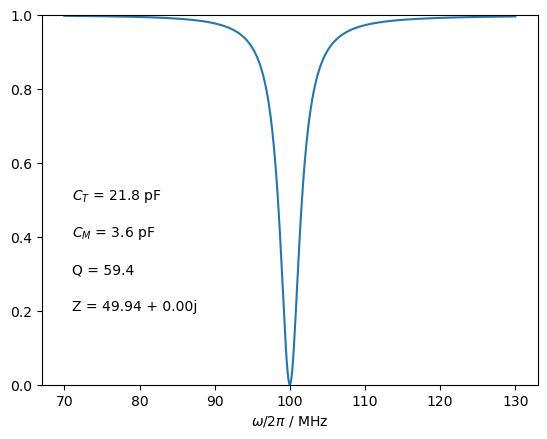

In [13]:
probe.RL=1
probe.RM=0
probe.RT=0
probe.CT=probe.CTmatch()
probe.CM=probe.CMmatch(analytic=False)
probe.tune()
_=probe.plot(v=np.linspace(70e6,130e6,500))